# Consignación SERMOTOR — nivel inicial y comparativo

Punto de partida para la consignación de rodamientos de SERMOTOR (`nit = 900611187`).
El cálculo usa 12 meses de consumo neto multimarca, incluyendo devoluciones DCC una
sola vez. No utiliza stock de seguridad, ADI, CV² ni percentiles.

## 1. Parámetros

Estos cuatro parámetros controlan la recomendación. El costo umbral corresponde al
par completo, no a una unidad.

In [1]:
MESES_COBERTURA = 2.5
UMBRAL_PAR      = 100_000
UMBRAL_SELLO    = 0.80
VENTANA_MESES   = 12
NIT             = "900611187"

from pathlib import Path
from io import StringIO
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scripts.analyze_sermotor_consignacion import (
    LISTA_CLIENTE_CSV,
    add_parser_columns,
    ceil_even,
    load_sales,
    normalize_designation,
    recent_costs,
)
from scripts.analyze_sermotor_nivel_inicial import skf_dispatch_reference

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
PESO = "${:,.0f}".format

## 2. Carga y normalización

Se filtra por NIT dentro de la consulta de lectura. El universo analizable contiene
únicamente rodamientos rígidos de bolas 608/60xx/62xx/63xx. El parser separa tamaño,
sello, juego y grasa; la marca permanece como atributo.

In [2]:
ventas = add_parser_columns(load_sales())
assert set(ventas["nit"].astype(str)) == {NIT}

fecha_max = ventas["fecha"].max().normalize()
fecha_inicio = fecha_max - pd.DateOffset(months=VENTANA_MESES) + pd.Timedelta(days=1)
es_rigido = ventas["nombreproducto"].fillna("").str.upper().eq("RODAMIENTO RIGIDO DE BOLAS")
universo = ventas[ventas["parser_ok"] & es_rigido].copy()
ventana = universo[universo["fecha"].between(fecha_inicio, fecha_max)].copy()

fallos = (
    ventas[es_rigido & ~ventas["parser_ok"]]
    .groupby(["prefijo_1", "parser_error"], dropna=False)
    .agg(volumen_neto=("cantidad", "sum"), lineas=("sales_line_key", "count"))
    .reset_index()
    .sort_values(["volumen_neto", "lineas"], ascending=False)
)

validacion = pd.DataFrame([
    normalize_designation("6204-C-2HRS-L038-C3"),
    normalize_designation("6205-2RSH/C3GJN"),
])[["raw", "llave_canonica", "grasa"]]
display(validacion)

resumen_carga = pd.DataFrame({
    "Indicador": [
        "Líneas totales del cliente",
        "Primera fecha disponible",
        "Última fecha disponible",
        "Líneas elegibles en ventana",
        "Líneas DCC elegibles en ventana",
        "Cantidad neta DCC en ventana",
        "Códigos fuera del parser/universo",
    ],
    "Valor": [
        f"{len(ventas):,}",
        ventas["fecha"].min().date().isoformat(),
        ventas["fecha"].max().date().isoformat(),
        f"{len(ventana):,}",
        f"{ventana['prefijo'].eq('DCC').sum():,}",
        f"{ventana.loc[ventana['prefijo'].eq('DCC'), 'cantidad'].sum():,.0f}",
        f"{len(fallos):,}",
    ],
})
display(resumen_carga)

,raw,llave_canonica,grasa
0,6204-C-2HRS-L038-C3,6204 | CAUCHO | C3,L038
1,6205-2RSH/C3GJN,6205 | CAUCHO | C3,GJN


,Indicador,Valor
0,Líneas totales del cliente,"3,047"
1,Primera fecha disponible,2023-01-03
2,Última fecha disponible,2026-07-21
3,Líneas elegibles en ventana,755
4,Líneas DCC elegibles en ventana,2
5,Cantidad neta DCC en ventana,-7
6,Códigos fuera del parser/universo,25


### Códigos no clasificados

Esta tabla es el control de calidad del parser. Incluye exclusiones deliberadas
(`NR`, 64xx y referencias fuera de las series objetivo) para que ninguna línea
desaparezca silenciosamente.

In [3]:
display(fallos)

,prefijo_1,parser_error,volumen_neto,lineas
24,R 6 ZZ TWN,TAMAÑO_NO_CLASIFICADO,10.0,5
1,16005-A,TAMAÑO_NO_CLASIFICADO,5.0,2
9,61900-2Z,TAMAÑO_NO_CLASIFICADO,4.0,3
13,626-2RSH/C3,TAMAÑO_NO_CLASIFICADO,4.0,2
21,R 6 LLU,TAMAÑO_NO_CLASIFICADO,4.0,1
23,R 6 ZZ,TAMAÑO_NO_CLASIFICADO,4.0,1
7,609-2Z/C3GJN,TAMAÑO_NO_CLASIFICADO,3.0,2
11,6208 ZZNR,ANILLO_NR_EXCLUIDO,3.0,2
19,6405-A-C3,TAMAÑO_NO_CLASIFICADO,2.0,2
0,16003-A-2Z,TAMAÑO_NO_CLASIFICADO,2.0,1


## 3. Consumo neto por llave canónica

Cada fila suma SKF, FAG, NTN y cualquier otra marca bajo la misma identidad técnica.
Las cantidades DCC negativas reducen el consumo.

In [4]:
consumo = (
    ventana.groupby(
        ["parser_llave_canonica", "parser_tamano", "parser_sello", "parser_juego"],
        dropna=False,
    )["cantidad"]
    .sum()
    .reset_index(name="consumo_12m")
    .rename(columns={
        "parser_llave_canonica": "llave_canonica",
        "parser_tamano": "tamano",
        "parser_sello": "sello",
        "parser_juego": "juego",
    })
)
consumo = consumo[consumo["consumo_12m"] > 0].copy()
consumo["consumo_mensual"] = consumo["consumo_12m"] / 12
display(consumo.sort_values("consumo_12m", ascending=False))

,llave_canonica,tamano,sello,juego,consumo_12m,consumo_mensual
40,6205 | METAL | C3,6205,METAL,C3,199.0,16.583333
42,6206 | METAL | C3,6206,METAL,C3,177.0,14.750000
39,6205 | CAUCHO | C3,6205,CAUCHO,C3,163.0,13.583333
32,6203 | CAUCHO | C3,6203,CAUCHO,C3,120.0,10.000000
37,6204 | METAL | C3,6204,METAL,C3,119.0,9.916667
41,6206 | CAUCHO | C3,6206,CAUCHO,C3,113.0,9.416667
33,6203 | METAL | C3,6203,METAL,C3,104.0,8.666667
30,6202 | METAL | C3,6202,METAL,C3,98.0,8.166667
36,6204 | CAUCHO | C3,6204,CAUCHO,C3,89.0,7.416667
75,6306 | METAL | C3,6306,METAL,C3,89.0,7.416667


## 4. Regla simple de nivel

El nivel crudo equivale al consumo mensual por los meses de cobertura. Solo el nivel
final se redondea hacia arriba a número par.

In [5]:
costos = recent_costs(universo)
base = consumo.merge(costos, on="llave_canonica", how="left")
assert base["costo_unitario_reciente"].notna().all(), "Hay referencias sin costo reciente"

base["nivel_crudo"] = base["consumo_mensual"] * MESES_COBERTURA
base["costo_par"] = 2 * base["costo_unitario_reciente"]
base["elegible_por_nivel"] = (
    base["nivel_crudo"].ge(2)
    | (
        base["nivel_crudo"].ge(1)
        & base["nivel_crudo"].lt(2)
        & base["costo_par"].lt(UMBRAL_PAR)
    )
)
base["motivo_nivel"] = np.select(
    [
        base["nivel_crudo"].lt(1),
        base["nivel_crudo"].ge(1) & base["nivel_crudo"].lt(2)
        & base["costo_par"].ge(UMBRAL_PAR),
    ],
    ["ROTACION_BAJA", "COSTO_ALTO"],
    default="",
)
base["nivel_pre_sello"] = np.where(
    base["elegible_por_nivel"], base["nivel_crudo"].map(ceil_even), 0
).astype(int)

display(base[[
    "llave_canonica", "consumo_12m", "consumo_mensual", "nivel_crudo",
    "costo_par", "nivel_pre_sello", "motivo_nivel",
]].sort_values("consumo_12m", ascending=False))

,llave_canonica,consumo_12m,consumo_mensual,nivel_crudo,costo_par,nivel_pre_sello,motivo_nivel
39,6205 | METAL | C3,199.0,16.583333,41.458333,2.263590e+04,42,
41,6206 | METAL | C3,177.0,14.750000,36.875000,4.003402e+04,38,
38,6205 | CAUCHO | C3,163.0,13.583333,33.958333,2.628894e+04,34,
31,6203 | CAUCHO | C3,120.0,10.000000,25.000000,1.938038e+04,26,
36,6204 | METAL | C3,119.0,9.916667,24.791667,1.955314e+04,26,
40,6206 | CAUCHO | C3,113.0,9.416667,23.541667,4.010481e+04,24,
32,6203 | METAL | C3,104.0,8.666667,21.666667,1.658149e+04,22,
29,6202 | METAL | C3,98.0,8.166667,20.416667,1.479430e+04,22,
35,6204 | CAUCHO | C3,89.0,7.416667,18.541667,2.192929e+04,20,
74,6306 | METAL | C3,89.0,7.416667,18.541667,5.300789e+04,20,


## 5. Consolidación 2Z frente a 2RS

La participación se calcula después de sumar todos los juegos de cada sello dentro
del tamaño. Si METAL o CAUCHO alcanza 80%, el otro sello se maneja contra pedido.
Las referencias abiertas se conservan separadas y deben superar por sí mismas la
regla de nivel.

In [6]:
sellados = base[base["sello"].isin(["METAL", "CAUCHO"])].copy()
dist_sello = (
    sellados.groupby(["tamano", "sello"])["consumo_12m"]
    .sum().reset_index(name="consumo_sello")
)
dist_sello["consumo_tamano_sellado"] = dist_sello.groupby("tamano")[
    "consumo_sello"
].transform("sum")
dist_sello["participacion"] = (
    dist_sello["consumo_sello"] / dist_sello["consumo_tamano_sellado"]
)
max_share = dist_sello.groupby("tamano")["participacion"].max()
dist_sello["regla_actua"] = dist_sello["tamano"].map(max_share).ge(UMBRAL_SELLO)
dist_sello["sello_seleccionado"] = (
    ~dist_sello["regla_actua"] | dist_sello["participacion"].ge(UMBRAL_SELLO)
)

base = base.merge(
    dist_sello[["tamano", "sello", "participacion", "regla_actua", "sello_seleccionado"]],
    on=["tamano", "sello"], how="left",
)
base["participacion"] = base["participacion"].fillna(1.0)
base["regla_actua"] = base["regla_actua"].fillna(False).astype(bool)
base["sello_seleccionado"] = base["sello_seleccionado"].fillna(True).astype(bool)
base["nivel_lh"] = np.where(
    base["elegible_por_nivel"] & base["sello_seleccionado"],
    base["nivel_pre_sello"], 0
).astype(int)
base["motivo_final"] = base["motivo_nivel"]
base.loc[
    base["elegible_por_nivel"] & ~base["sello_seleccionado"], "motivo_final"
] = "CONSOLIDACION_SELLO"

tamanos_actuados = (
    dist_sello[dist_sello["regla_actua"]]
    .pivot(index="tamano", columns="sello", values="participacion")
    .fillna(0).reset_index()
)
for columna in ["METAL", "CAUCHO"]:
    if columna not in tamanos_actuados:
        tamanos_actuados[columna] = 0.0
display(
    tamanos_actuados.style.format({"METAL": "{:.1%}", "CAUCHO": "{:.1%}"})
)

/var/folders/6v/r4t6qrjx0tz5cmlchf8bqs5h0000gn/T/ipykernel_19752/347024235.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base["regla_actua"] = base["regla_actua"].fillna(False).astype(bool)
/var/folders/6v/r4t6qrjx0tz5cmlchf8bqs5h0000gn/T/ipykernel_19752/347024235.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base["sello_seleccionado"] = base["sello_seleccionado"].fillna(True).astype(bool)


sello,tamano,CAUCHO,METAL
0,6001,100.0%,0.0%
1,6002,0.0%,100.0%
2,6006,0.0%,100.0%
3,6007,0.0%,100.0%
4,6008,0.0%,100.0%
5,6011,100.0%,0.0%
6,6016,100.0%,0.0%
7,6018,0.0%,100.0%
8,6200,0.0%,100.0%
9,6214,100.0%,0.0%


## 6. Comparativo cliente frente a Lugo Hermanos

La tabla incluye la unión completa entre lo solicitado y lo que califica. Los
desacuerdos aparecen primero. La razón está redactada para poder compartir la tabla
sin explicación adicional.

In [7]:
lista_cliente = pd.read_csv(StringIO(LISTA_CLIENTE_CSV))
lista_parseada = pd.DataFrame(
    lista_cliente["referencia"].map(normalize_designation).tolist(),
    index=lista_cliente.index,
).add_prefix("parser_")
lista_cliente = pd.concat([lista_cliente, lista_parseada], axis=1)
assert lista_cliente["parser_ok"].all()
cliente = (
    lista_cliente.groupby("parser_llave_canonica")
    .agg(
        sugerido_cliente=("unidades", "sum"),
        referencias_cliente=("referencia", lambda x: "|".join(x)),
    )
    .reset_index()
    .rename(columns={"parser_llave_canonica": "llave_canonica"})
)

base["referencia_skf"] = base["llave_canonica"].map(
    lambda key: skf_dispatch_reference(key, universo)
)
comparativo = base.merge(cliente, on="llave_canonica", how="outer")
comparativo["sugerido_cliente"] = comparativo["sugerido_cliente"].fillna(0).astype(int)
for col in ["consumo_12m", "consumo_mensual", "nivel_lh", "nivel_crudo"]:
    comparativo[col] = comparativo[col].fillna(0)
comparativo["nivel_lh"] = comparativo["nivel_lh"].astype(int)

# Completa referencia y costo para llaves que solo están en la lista del cliente.
comparativo["referencia_skf"] = comparativo["referencia_skf"].fillna(
    comparativo["referencias_cliente"].str.split("|").str[0]
)
comparativo = comparativo.merge(
    costos.rename(columns={"costo_unitario_reciente": "costo_respaldo"})[
        ["llave_canonica", "costo_respaldo"]
    ],
    on="llave_canonica", how="left",
)
comparativo["costo_unitario"] = comparativo["costo_unitario_reciente"].fillna(
    comparativo["costo_respaldo"]
)
comparativo["diferencia"] = (
    comparativo["nivel_lh"] - comparativo["sugerido_cliente"]
)
comparativo["meses_cobertura_sugerido"] = np.where(
    comparativo["consumo_mensual"] > 0,
    comparativo["sugerido_cliente"] / comparativo["consumo_mensual"],
    np.nan,
)
comparativo["valor_costo_lh"] = (
    comparativo["nivel_lh"] * comparativo["costo_unitario"]
)

def estado(row):
    cliente_u, lh_u = row["sugerido_cliente"], row["nivel_lh"]
    if cliente_u > 0 and lh_u == 0:
        return "NO_ENTRA"
    if cliente_u == 0 and lh_u > 0:
        return "AGREGAR"
    if lh_u > cliente_u:
        return "SUBIR"
    if lh_u < cliente_u:
        return "BAJAR"
    return "COINCIDE"

comparativo["estado"] = comparativo.apply(estado, axis=1)

last_movement = universo.groupby("parser_llave_canonica")["fecha"].max()
selected_by_size_seal = (
    base[base["nivel_lh"] > 0]
    .sort_values(["tamano", "nivel_lh"], ascending=[True, False])
)

def razon(row):
    consumo = row["consumo_12m"]
    mensual = row["consumo_mensual"]
    state = row["estado"]
    key = row["llave_canonica"]
    size = key.split(" | ")[0]
    if state == "NO_ENTRA":
        if consumo == 0:
            last = last_movement.get(key, pd.NaT)
            suffix = (
                f"último movimiento: {last:%Y-%m}"
                if pd.notna(last) else "sin movimiento histórico"
            )
            return f"Sin consumo en 12 meses ({suffix})."
        if row.get("motivo_final") == "CONSOLIDACION_SELLO":
            selected = selected_by_size_seal[
                selected_by_size_seal["tamano"].eq(size)
            ].iloc[0]
            share = selected["participacion"]
            return (
                f"El tamaño {size} consume {share:.0%} en "
                f"{'2Z' if selected['sello'] == 'METAL' else '2RS'}. "
                f"Se consolida en {selected['referencia_skf']} "
                f"(nivel {selected['nivel_lh']})."
            )
        if row.get("motivo_final") == "COSTO_ALTO":
            return (
                f"Consumo de {consumo:.0f} und/año pero el par cuesta "
                f"{PESO(row['costo_par'])}. Se maneja contra pedido."
            )
        crudo = row["nivel_crudo"]
        return (
            f"Consumo de {consumo:.0f} und/año ({mensual:.1f}/mes). "
            f"Con {MESES_COBERTURA:g} meses de cobertura da {crudo:.1f} und. "
            "Se maneja contra pedido, entrega 24-48h."
        )
    if state == "AGREGAR":
        other = ventana[
            ventana["parser_llave_canonica"].eq(key) & ventana["sufijo"].ne("SKF")
        ]
        brand = (
            other.groupby("sufijo")["cantidad"].sum().idxmax()
            if not other.empty else "otra marca"
        )
        return (
            f"Consumo de {consumo:.0f} und/año, no estaba en la lista. "
            f"Hoy se surte con {brand}."
        )
    if state == "SUBIR":
        days = (
            row["sugerido_cliente"] / mensual * (365 / 12)
            if mensual > 0 else 0
        )
        return (
            f"Consumo de {consumo:.0f} und/año ({mensual:.1f}/mes). "
            f"Lo sugerido cubre {days:.1f} días."
        )
    if state == "BAJAR":
        return (
            f"Consumo de {consumo:.0f} und/año ({mensual:.1f}/mes). "
            f"Lo sugerido cubre {row['meses_cobertura_sugerido']:.1f} meses."
        )
    return f"Consumo de {consumo:.0f} und/año. Coincide con lo sugerido."

comparativo["razon"] = comparativo.apply(razon, axis=1)
order = {"NO_ENTRA": 0, "BAJAR": 1, "SUBIR": 2, "AGREGAR": 3, "COINCIDE": 4}
comparativo["_orden"] = comparativo["estado"].map(order)
comparativo = comparativo.sort_values(
    ["_orden", "valor_costo_lh"], ascending=[True, False], na_position="last"
)

tabla_principal = comparativo[[
    "referencia_skf", "sugerido_cliente", "nivel_lh", "diferencia",
    "consumo_12m", "consumo_mensual", "meses_cobertura_sugerido",
    "costo_unitario", "valor_costo_lh", "estado", "razon",
]].rename(columns={
    "referencia_skf": "Referencia SKF",
    "sugerido_cliente": "Sugerido cliente",
    "nivel_lh": "Calculado LH",
    "diferencia": "Diferencia",
    "consumo_12m": "Consumo 12m",
    "consumo_mensual": "Consumo mensual",
    "meses_cobertura_sugerido": "Meses cobertura sugerido",
    "costo_unitario": "Costo unitario",
    "valor_costo_lh": "Valor a costo LH",
    "estado": "Estado",
    "razon": "Razón",
})
display(tabla_principal.style.format({
    "Sugerido cliente": "{:,.0f}",
    "Calculado LH": "{:,.0f}",
    "Diferencia": "{:+,.0f}",
    "Consumo 12m": "{:,.1f}",
    "Consumo mensual": "{:,.1f}",
    "Meses cobertura sugerido": "{:,.1f}",
    "Costo unitario": PESO,
    "Valor a costo LH": PESO,
}, na_rep="—"))

,Referencia SKF,Sugerido cliente,Calculado LH,Diferencia,Consumo 12m,Consumo mensual,Meses cobertura sugerido,Costo unitario,Valor a costo LH,Estado,Razón
3,6002-2Z/C3GJN,2,0,-2,3.0,0.2,8.0,"$8,392",$0,NO_ENTRA,"Consumo de 3 und/año (0.2/mes). Con 2.5 meses de cobertura da 0.6 und. Se maneja contra pedido, entrega 24-48h."
52,6211-2Z/C3GJN,1,0,-1,4.0,0.3,3.0,"$70,261",$0,NO_ENTRA,"Consumo de 4 und/año (0.3/mes). Con 2.5 meses de cobertura da 0.8 und. Se maneja contra pedido, entrega 24-48h."
57,6213-2RS1/C3GJN,2,0,-2,8.0,0.7,3.0,"$131,629",$0,NO_ENTRA,"Consumo de 8 und/año pero el par cuesta $263,259. Se maneja contra pedido."
58,6213-2Z/C3GJN,1,0,-1,5.0,0.4,2.4,"$127,723",$0,NO_ENTRA,"Consumo de 5 und/año pero el par cuesta $255,447. Se maneja contra pedido."
64,6300-2Z/C3GJN,2,0,-2,0.0,0.0,—,"$13,508",$0,NO_ENTRA,Sin consumo en 12 meses (último movimiento: 2025-05).
83,6310-2Z/C3GJN,2,0,-2,9.0,0.8,2.7,"$99,036",$0,NO_ENTRA,"Consumo de 9 und/año pero el par cuesta $198,072. Se maneja contra pedido."
93,6314-2Z/C3GJN,1,0,-1,5.0,0.4,2.4,"$291,877",$0,NO_ENTRA,"Consumo de 5 und/año pero el par cuesta $583,755. Se maneja contra pedido."
99,6316-2RS1/C3,1,0,-1,8.0,0.7,1.5,"$522,572",$0,NO_ENTRA,"Consumo de 8 und/año pero el par cuesta $1,045,144. Se maneja contra pedido."
101,6317-2RS1/C3GJN,1,0,-1,0.0,0.0,—,"$842,738",$0,NO_ENTRA,Sin consumo en 12 meses (último movimiento: 2025-04).
104,6318-2Z/C3GJN,1,0,-1,0.0,0.0,—,"$549,758",$0,NO_ENTRA,Sin consumo en 12 meses (último movimiento: 2025-05).


### Resumen por estado

Las unidades del cliente y de LH permiten separar el efecto de cada desacuerdo; el
capital corresponde exclusivamente al nivel calculado por LH.

In [8]:
por_estado = (
    comparativo.groupby("estado", observed=True)
    .agg(
        referencias=("llave_canonica", "size"),
        unidades_cliente=("sugerido_cliente", "sum"),
        unidades_lh=("nivel_lh", "sum"),
        capital_lh=("valor_costo_lh", "sum"),
    )
    .reindex(["NO_ENTRA", "BAJAR", "SUBIR", "AGREGAR", "COINCIDE"])
    .dropna(how="all")
    .reset_index()
)
display(por_estado.style.format({
    "referencias": "{:,.0f}",
    "unidades_cliente": "{:,.0f}",
    "unidades_lh": "{:,.0f}",
    "capital_lh": PESO,
}))

,estado,referencias,unidades_cliente,unidades_lh,capital_lh
0,NO_ENTRA,10,14,0,$0
1,SUBIR,46,147,552,"$19,509,129"
2,AGREGAR,5,0,12,"$129,014"
3,COINCIDE,47,6,6,"$75,145"


## 7. Sensibilidad a los meses de cobertura

La consolidación por sello se mantiene fija; para cada escenario se vuelve a aplicar
la elegibilidad, el umbral del par y el redondeo a pares.

,Meses,Referencias que entran,Unidades,Capital a costo
0,1.5,44,343,"$10,012,442"
1,2.0,46,436,"$13,079,418"
2,2.5,54,570,"$19,713,287"
3,3.0,60,675,"$24,067,435"
4,4.0,63,877,"$30,705,651"


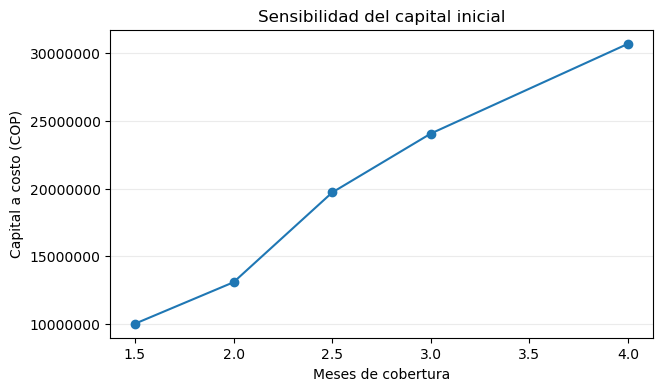

In [9]:
def escenario(meses):
    x = base.copy()
    x["crudo"] = x["consumo_mensual"] * meses
    x["entra_nivel"] = (
        x["crudo"].ge(2)
        | (
            x["crudo"].ge(1) & x["crudo"].lt(2)
            & x["costo_par"].lt(UMBRAL_PAR)
        )
    )
    x["nivel"] = np.where(
        x["entra_nivel"] & x["sello_seleccionado"],
        x["crudo"].map(ceil_even), 0
    ).astype(int)
    x["capital"] = x["nivel"] * x["costo_unitario_reciente"]
    return {
        "Meses": meses,
        "Referencias que entran": int(x["nivel"].gt(0).sum()),
        "Unidades": int(x["nivel"].sum()),
        "Capital a costo": x["capital"].sum(),
    }

sensibilidad = pd.DataFrame([escenario(m) for m in [1.5, 2, 2.5, 3, 4]])
display(sensibilidad.style.format({
    "Meses": "{:.1f}",
    "Referencias que entran": "{:,.0f}",
    "Unidades": "{:,.0f}",
    "Capital a costo": PESO,
}))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sensibilidad["Meses"], sensibilidad["Capital a costo"], marker="o")
ax.set_xlabel("Meses de cobertura")
ax.set_ylabel("Capital a costo (COP)")
ax.set_title("Sensibilidad del capital inicial")
ax.grid(axis="y", alpha=0.25)
ax.ticklabel_format(style="plain", axis="y")
plt.show()

## 8. Resumen ejecutivo

La propuesta simple se compara con los dos puntos de referencia conocidos. El nivel
estadístico se muestra únicamente como antecedente descartado.

In [10]:
resumen = pd.DataFrame([
    {
        "Escenario": "Lista del cliente",
        "Referencias": 59,
        "Unidades": 167,
        "Capital a costo": 9_096_247,
    },
    {
        "Escenario": f"Regla simple ({MESES_COBERTURA:g} meses)",
        "Referencias": int((comparativo["nivel_lh"] > 0).sum()),
        "Unidades": int(comparativo["nivel_lh"].sum()),
        "Capital a costo": comparativo["valor_costo_lh"].sum(),
    },
    {
        "Escenario": "Propuesta estadística descartada",
        "Referencias": 72,
        "Unidades": 449,
        "Capital a costo": 19_464_306,
    },
])
display(resumen.style.format({
    "Referencias": "{:,.0f}",
    "Unidades": "{:,.0f}",
    "Capital a costo": PESO,
}))

,Escenario,Referencias,Unidades,Capital a costo
0,Lista del cliente,59,167,"$9,096,247"
1,Regla simple (2.5 meses),54,570,"$19,713,287"
2,Propuesta estadística descartada,72,449,"$19,464,306"


## Exportación opcional

El notebook es el entregable principal. Cambie `EXPORTAR` a `True` solo si necesita
enviar las tablas fuera del notebook.

In [11]:
EXPORTAR = False
if EXPORTAR:
    destino = Path("outputs/sermotor_notebook")
    destino.mkdir(parents=True, exist_ok=True)
    tabla_principal.to_csv(destino / "comparativo.csv", index=False)
    sensibilidad.to_csv(destino / "sensibilidad.csv", index=False)
    resumen.to_csv(destino / "resumen.csv", index=False)
    print(f"Exportado en {destino.resolve()}")
else:
    print("Exportación desactivada.")

Exportación desactivada.
